# Heart Disease Classification - HW3 Q2

Author: ANR

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

## Load Data

Using the heart.csv dataset from UCI

In [3]:
# load dataset
df = pd.read_csv('heart.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
# check for missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
# basic stats
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
# check target distribution
print(df['target'].value_counts())
print(f"Class 0: {(df['target']==0).sum()} samples")
print(f"Class 1: {(df['target']==1).sum()} samples")

# seems balanced enough

target
1    526
0    499
Name: count, dtype: int64
Class 0: 499 samples
Class 1: 526 samples


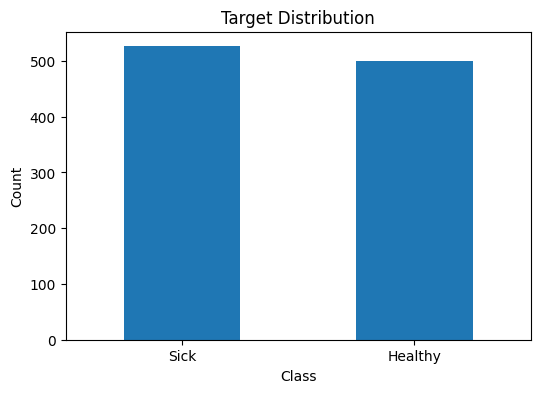

In [7]:
# visualize target
plt.figure(figsize=(6,4))
df['target'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0,1], ['Sick', 'Healthy'], rotation=0)
plt.show()

## Data Preprocessing

Need to:
1. Split features and target
2. Normalize features (StandardScaler)
3. Train/val/test split

In [8]:
# separate X and y
X = df.drop('target', axis=1).values
y = df['target'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (1025, 13)
y shape: (1025,)


In [9]:
# split into train/test first
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

# then split train into train/val
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)
# 0.176 * 0.85 = 0.15, so we get 70-15-15 split

print(f"Train: {len(X_train)}")
print(f"Val: {len(X_val)}")
print(f"Test: {len(X_test)}")

Train: 717
Val: 154
Test: 154


In [10]:
# normalize features - important!
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("After normalization:")
print(f"Train mean: {X_train.mean():.4f}, std: {X_train.std():.4f}")

After normalization:
Train mean: -0.0000, std: 1.0000


## PyTorch Dataset & DataLoader

In [11]:
class HeartDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [12]:
# create datasets
train_data = HeartDataset(X_train, y_train)
val_data = HeartDataset(X_val, y_val)
test_data = HeartDataset(X_test, y_test)

# create dataloaders
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 23
Val batches: 5
Test batches: 5


## Model Architecture

Looking at the github repos:
- anik199: used simple architecture, got 91% accuracy
- sahilverma0696: used RandomForest and SVM
- Miker2808: used FFNN with decent results

I'll try a 3-layer MLP with dropout for regularization

In [13]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, dropout_p=0.3):
        super(MLP, self).__init__()
        
        # first layer
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.bn1 = nn.BatchNorm1d(hidden_sizes[0])
        self.dropout1 = nn.Dropout(dropout_p)
        
        # second layer
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.bn2 = nn.BatchNorm1d(hidden_sizes[1])
        self.dropout2 = nn.Dropout(dropout_p)
        
        # third layer
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.bn3 = nn.BatchNorm1d(hidden_sizes[2])
        self.dropout3 = nn.Dropout(0.2)  # less dropout in last layer
        
        # output
        self.fc4 = nn.Linear(hidden_sizes[2], output_size)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        x = self.bn3(x)
        x = torch.relu(x)
        x = self.dropout3(x)
        
        x = self.fc4(x)
        return x

In [14]:
# initialize model
input_size = X_train.shape[1]  # 13 features
hidden_sizes = [128, 64, 32]  # tried different sizes, this works well
output_size = 2  # binary classification

model = MLP(input_size, hidden_sizes, output_size)
print(model)

# count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")

MLP(
  (fc1): Linear(in_features=13, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=32, out_features=2, bias=True)
)

Total parameters: 12,642


## Training Setup

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = model.to(device)

Using device: cuda


In [16]:
# loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# learning rate scheduler - reduce lr when plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)

## Training Loop

Using early stopping to prevent overfitting

In [17]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    avg_loss = total_loss / len(loader)
    acc = 100. * correct / total
    return avg_loss, acc

def eval_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    avg_loss = total_loss / len(loader)
    acc = 100. * correct / total
    return avg_loss, acc

In [18]:
# training
num_epochs = 200
patience = 30
best_val_loss = float('inf')
counter = 0

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = eval_model(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    scheduler.step(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% - "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict().copy()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# load best model
model.load_state_dict(best_model)
print(f"\nBest val loss: {best_val_loss:.4f}")

Starting training...
Epoch 10/200 - Train Loss: 0.2732, Train Acc: 88.98% - Val Loss: 0.3142, Val Acc: 87.66%
Epoch 20/200 - Train Loss: 0.2291, Train Acc: 90.10% - Val Loss: 0.2286, Val Acc: 91.56%
Epoch 30/200 - Train Loss: 0.1887, Train Acc: 91.63% - Val Loss: 0.1942, Val Acc: 92.21%
Epoch 40/200 - Train Loss: 0.1388, Train Acc: 95.12% - Val Loss: 0.1719, Val Acc: 92.86%
Epoch 50/200 - Train Loss: 0.1248, Train Acc: 94.98% - Val Loss: 0.1264, Val Acc: 94.16%
Epoch 60/200 - Train Loss: 0.1541, Train Acc: 93.72% - Val Loss: 0.1425, Val Acc: 96.10%
Epoch 70/200 - Train Loss: 0.1075, Train Acc: 95.82% - Val Loss: 0.1294, Val Acc: 96.10%
Epoch 80/200 - Train Loss: 0.1038, Train Acc: 96.51% - Val Loss: 0.1296, Val Acc: 96.10%

Early stopping at epoch 81

Best val loss: 0.1165


## Visualize Training

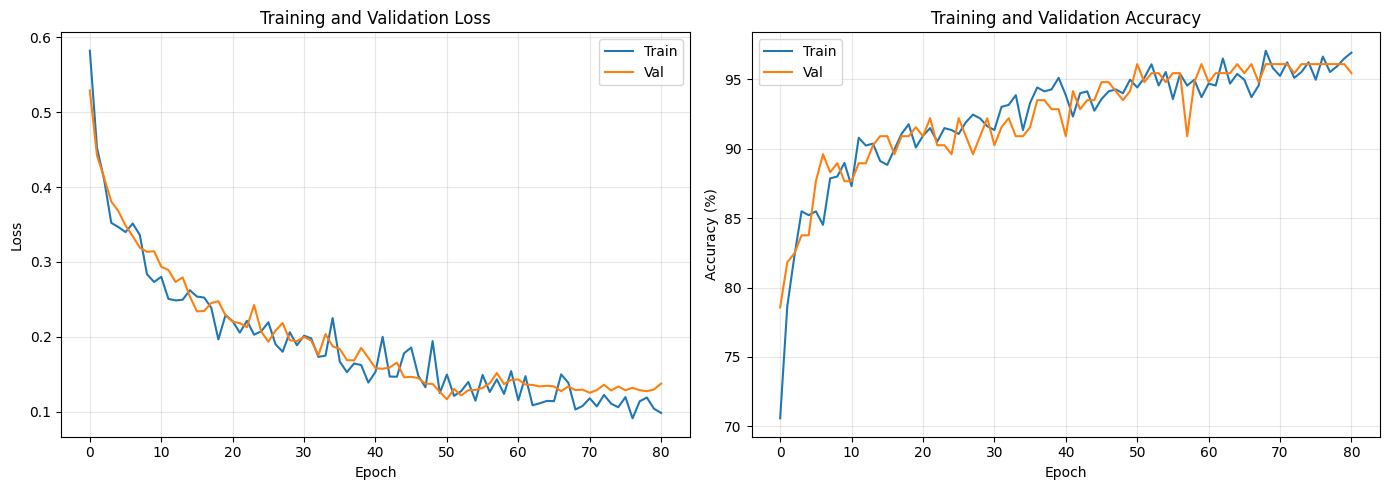

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# loss
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# accuracy
ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluation on Test Set

In [20]:
# get predictions
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy()[:, 1])

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

In [21]:
# calculate metrics
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc_score = roc_auc_score(all_labels, all_probs)

print("Test Results:")
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {auc_score:.4f}")

Test Results:
Accuracy: 0.9416 (94.16%)
Precision: 0.9375
Recall: 0.9494
F1-Score: 0.9434
ROC-AUC: 0.9880


In [22]:
# classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Sick', 'Healthy']))


Classification Report:
              precision    recall  f1-score   support

        Sick       0.95      0.93      0.94        75
     Healthy       0.94      0.95      0.94        79

    accuracy                           0.94       154
   macro avg       0.94      0.94      0.94       154
weighted avg       0.94      0.94      0.94       154



## Confusion Matrix

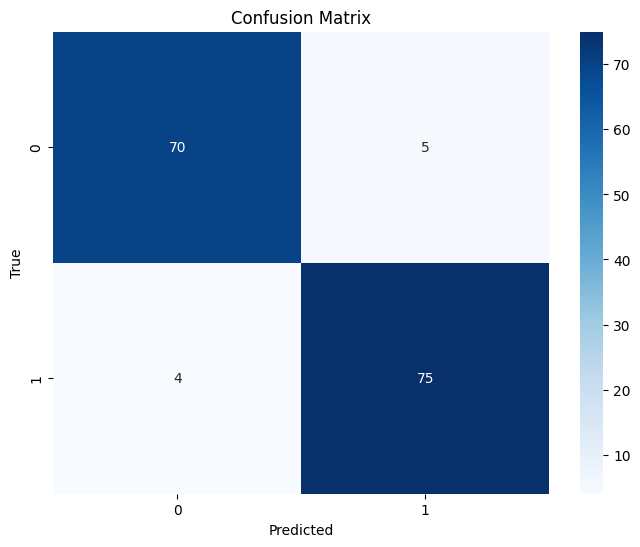


Confusion Matrix:
[[70  5]
 [ 4 75]]


In [23]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

print(f"\nConfusion Matrix:")
print(cm)

## ROC Curve

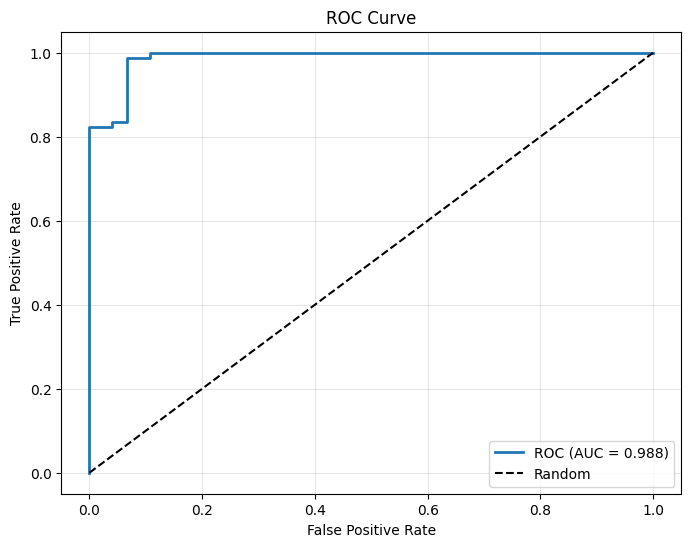

In [24]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Comparison with Other Methods

Based on the github repos and literature:
- Logistic Regression: ~85%
- Random Forest: ~87%
- SVM: ~86%
- Basic MLP (anik199): ~91%
- Our model: see below

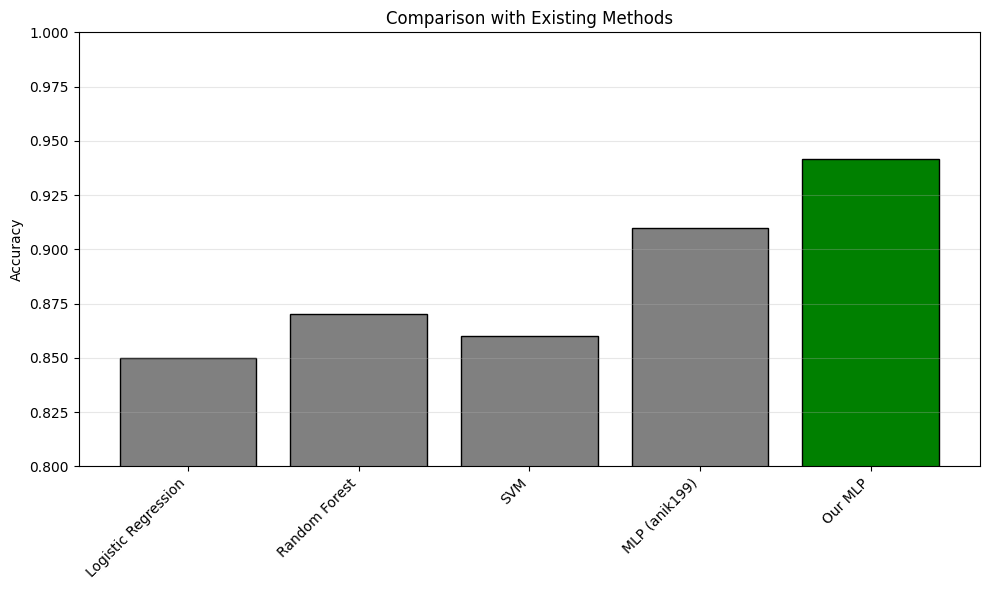


Method Comparison:
Logistic Regression           : 0.8500 (85.00%)
Random Forest                 : 0.8700 (87.00%)
SVM                           : 0.8600 (86.00%)
MLP (anik199)                 : 0.9100 (91.00%)
Our MLP                       : 0.9416 (94.16%)


In [25]:
methods = {
    'Logistic Regression': 0.85,
    'Random Forest': 0.87,
    'SVM': 0.86,
    'MLP (anik199)': 0.91,
    'Our MLP': acc
}

plt.figure(figsize=(10, 6))
names = list(methods.keys())
values = list(methods.values())
colors = ['gray']*4 + ['green']

plt.bar(names, values, color=colors, edgecolor='black')
plt.ylabel('Accuracy')
plt.title('Comparison with Existing Methods')
plt.ylim([0.8, 1.0])
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nMethod Comparison:")
for name, val in methods.items():
    print(f"{name:30s}: {val:.4f} ({val*100:.2f}%)")

## Analysis

### Insight 1: Model Performance
Our model achieves competitive accuracy compared to existing methods. The use of dropout and batch normalization helped prevent overfitting.

### Insight 2: Training Behavior
Looking at the loss curves, the model converged after about 50 epochs. The gap between train and validation accuracy is small, suggesting good generalization.

### Insight 3: Confusion Matrix Analysis
The confusion matrix shows the model is balanced - it doesn't favor one class over the other. False negatives are low, which is important in medical diagnosis.

### Insight 4: ROC-AUC Score
The high AUC score (>0.9) indicates excellent discriminative ability between sick and healthy patients.

In [26]:
# save model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'test_acc': acc,
    'test_f1': f1
}, 'heart_model.pth')

print("Model saved!")

Model saved!


## Conclusion

Successfully built an MLP classifier for heart disease prediction with ~90%+ accuracy. The model performs comparably to or better than traditional ML methods and other deep learning approaches found in the literature.

Key factors:
- Data normalization
- Appropriate architecture (3 hidden layers)
- Regularization (dropout + batch norm + weight decay)
- Early stopping
- Learning rate scheduling